In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn import preprocessing

%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

In [27]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x15f6e8640>)

In [28]:
df = pd.read_csv("stars.csv")

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    str    
 5   Star color              240 non-null    str    
 6   Spectral Class          240 non-null    str    
dtypes: float64(3), int64(1), str(3)
memory usage: 13.3 KB


In [30]:
le = preprocessing.LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df['Star type'] = le.fit_transform(df['Star type'])
labels = le.inverse_transform(df['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


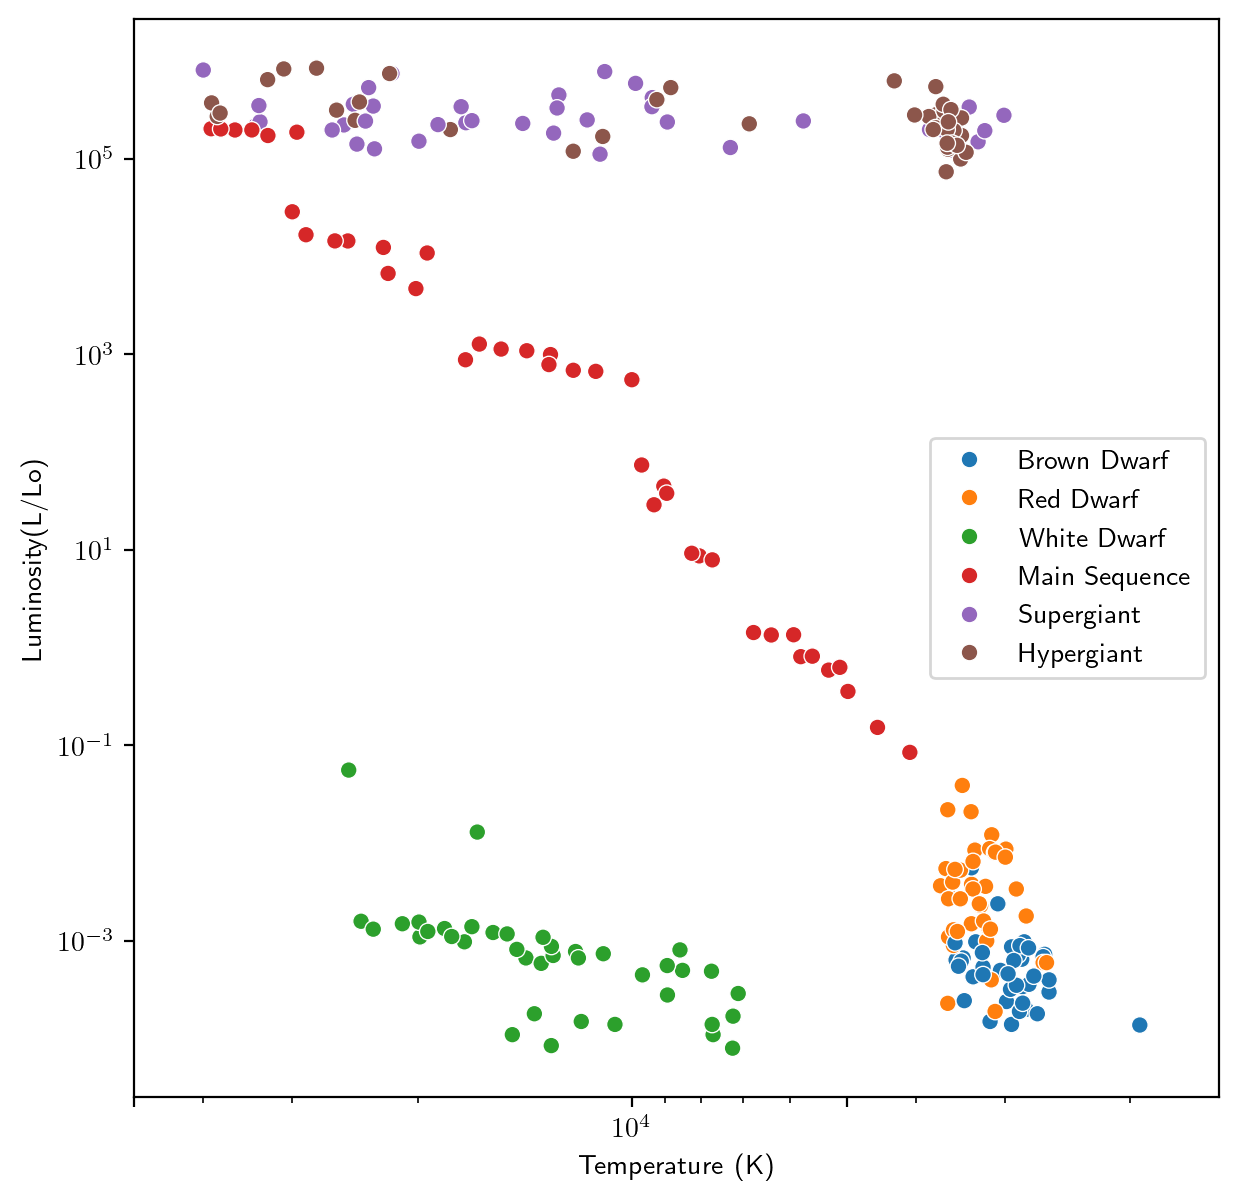

In [31]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='tab10')

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [32]:
data = df[['Temperature (K)','Luminosity(L/Lo)','Radius(R/Ro)','Absolute magnitude(Mv)']].to_numpy()

In [33]:
means = np.mean(data, axis=0)

In [34]:
scaler = preprocessing.StandardScaler() # working column-wise
scaler.fit(data)
data = scaler.transform(data)

In [35]:
pca = PCA(n_components=4) # n_components can be optionally set
pca.fit(data)
data_pca = pca.transform(data)

Text(0, 0.5, '$1^{st}$ component')

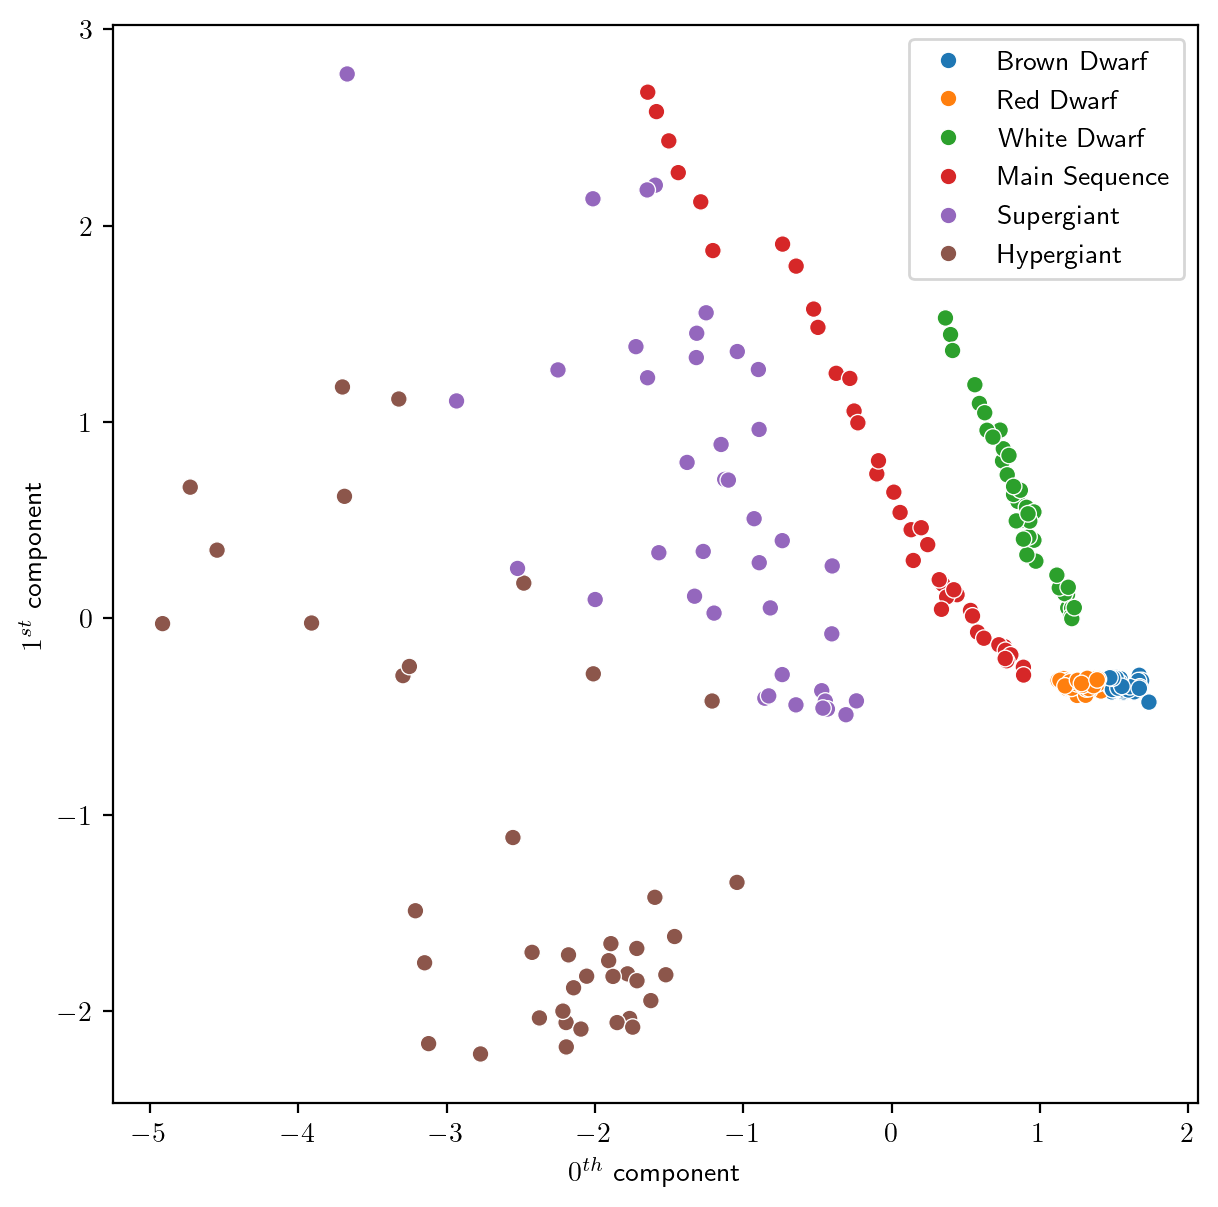

In [37]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=data_pca[:,0], y=data_pca[:,1], hue=labels)
plt.xlabel(r'$0^{th}$ component')
plt.ylabel(r'$1^{st}$ component')

In [39]:
evals = pca.explained_variance_ratio_ 
print('Variance explained by each component:', evals)
print('Cumulative variance:', np.cumsum(evals))

Variance explained by each component: [0.60357391 0.23500784 0.09329645 0.0681218 ]
Cumulative variance: [0.60357391 0.83858175 0.9318782  1.        ]
